# Reliable and Explainable Customer Churn Prediction - Notebook

### Academic Year Dissertation - 2025/2026

Student Name / Number: Onyekachukwu Innocent Ekesi / 25139718

Module Code: PROJ518

Module Title: MSc Dissertation and Research Skills

Module Leader: Dr Martyn Hann

Dissertation Supervisor: Dr Craig McNeile

School: School of Engineering, Computing and Mathematics


##1.0 Import Libraries

In [1]:
!pip install mapie --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.6/555.6 kB 8.7 MB/s eta 0:00:00


In [2]:
# We import the required dependencies
import pandas as pd # organizing dataframes
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

from mapie.classification import SplitConformalClassifier

from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import roc_auc_score, classification_report, roc_curve

from mapie.classification import SplitConformalClassifier

from sklearn.inspection import PartialDependenceDisplay

from sklearn.metrics import precision_recall_curve, average_precision_score

import shap

import joblib

import timeit

%matplotlib inline

## 1.1 Load the Data

In [5]:
# Loading the csv file
df1 = pd.read_csv('/content/churn.csv')

## 2.0 Exploratory Data Analysis
#### We take a view of the first 5 rows of the Dataset

1. We take a look at the dataset summary
2. We evaluate the relationship between the variables using the pearson correlation plot.
3. We visualize the distribution of numerical features.
4. We take a look at the target variable to see the distribution.
5. We evaluate how non-numerical features affect the target variable.

In [6]:
# A view of the first 5 rows of the dataset
df1.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# ------------------------------------------------------------
# 1. DATASET SUMMARY
# ------------------------------------------------------------

print("The Bank Churn dataset has ", df1.shape[0], " rows and ", df1.shape[1], " columns")

print("\nDataset Information:")
df1.info()

print("\nDescriptive Statistics:")
display(df1.describe(include="all").T)

print("\nMissing Values:")
display(df1.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:")
print(df1.duplicated().sum())

The Bank Churn dataset has  10000  rows and  14  columns

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Descriptive St

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0



Missing Values:


,Missing Values
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0



Duplicate Rows:
0


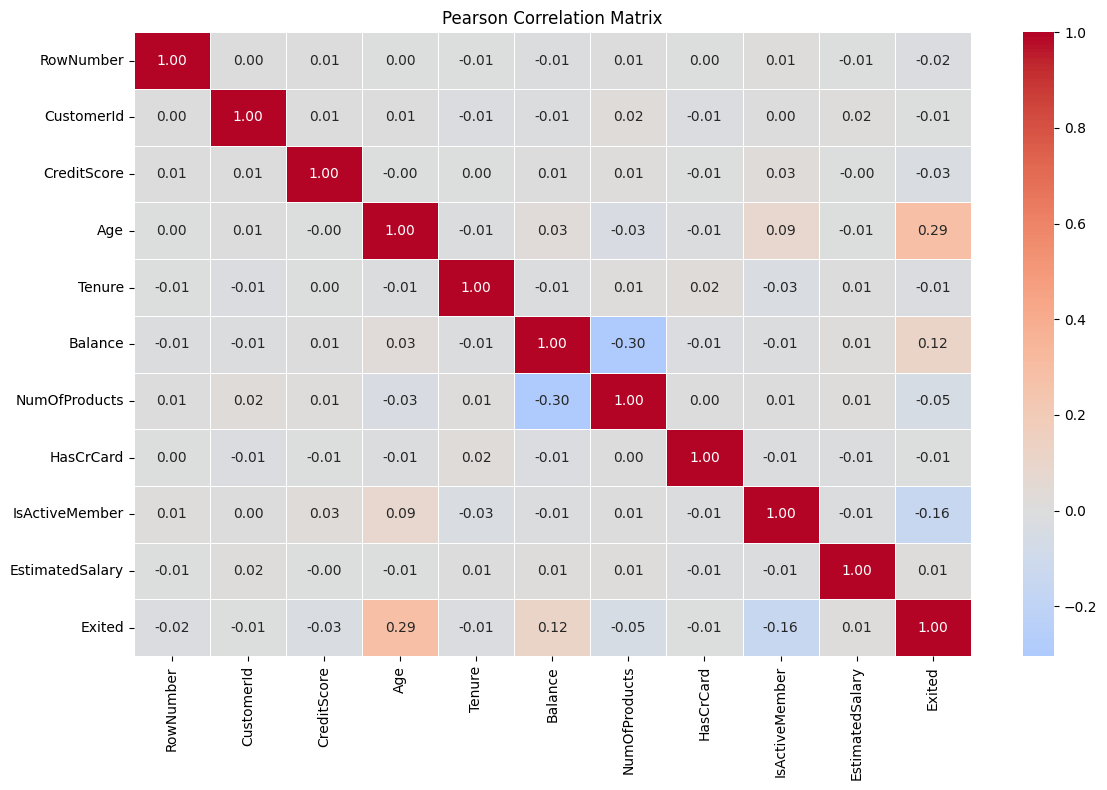

In [8]:
# ------------------------------------------------------------
# 2A. PEARSON CORRELATION ANALYSIS
# ------------------------------------------------------------

# Select numerical variables
numeric_df = df1.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr(method="pearson")

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()

# Save before showing
#plt.savefig('correlation1.png', dpi=300, bbox_inches='tight')

plt.show()

,Pearson Correlation with Churn
Age,0.285323
IsActiveMember,-0.156128
Balance,0.118533
NumOfProducts,-0.047820
CreditScore,-0.027094
RowNumber,-0.016571
Tenure,-0.014001
EstimatedSalary,0.012097
HasCrCard,-0.007138
CustomerId,-0.006248


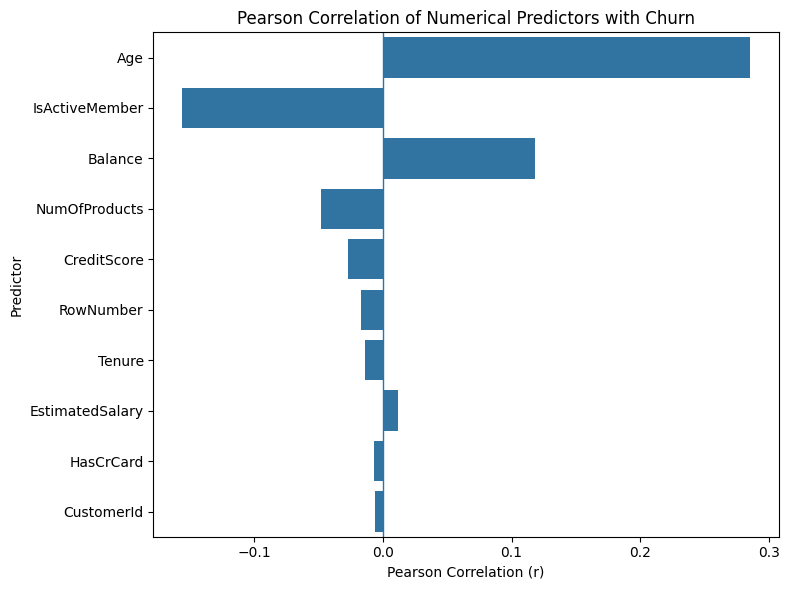

In [9]:
# ------------------------------------------------------------
# 2B. PREDICTOR-TARGET CORRELATION
# ------------------------------------------------------------

target_correlation = (
    correlation_matrix["Exited"]
    .drop("Exited")
    .sort_values(key=abs, ascending=False)
)

target_correlation_df = (
    target_correlation
    .to_frame(name="Pearson Correlation with Churn")
)

display(target_correlation_df)


# Visualisation of Predictor-target correlation
plt.figure(figsize=(8, 6))

sns.barplot(
    x=target_correlation.values,
    y=target_correlation.index
)

plt.axvline(0, linewidth=1)

plt.title("Pearson Correlation of Numerical Predictors with Churn")
plt.xlabel("Pearson Correlation (r)")
plt.ylabel("Predictor")

plt.tight_layout()

# Save before showing
#plt.savefig('correlation2.png', dpi=300, bbox_inches='tight')

plt.show()

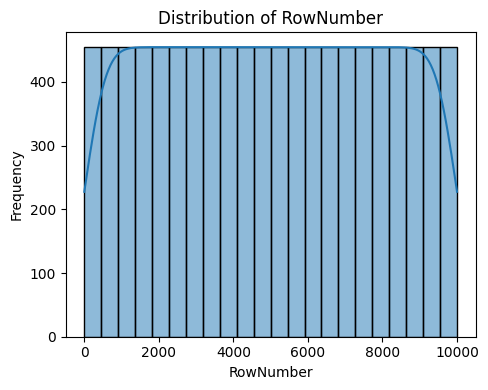

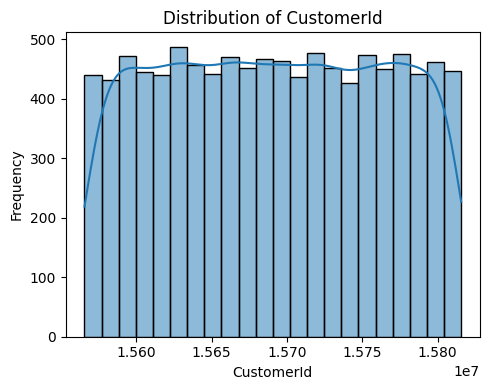

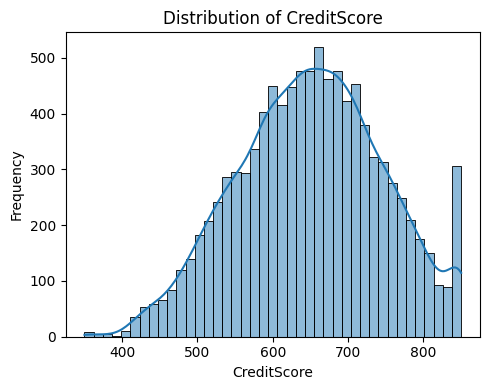

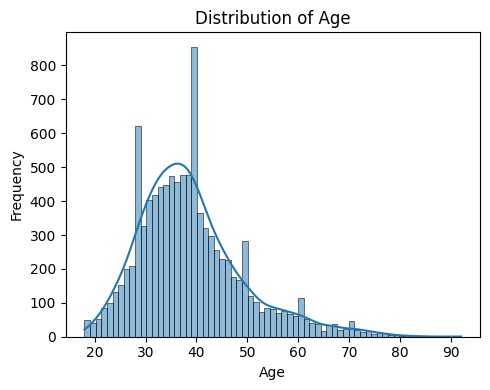

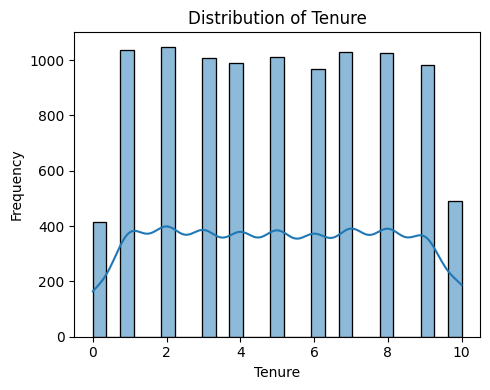

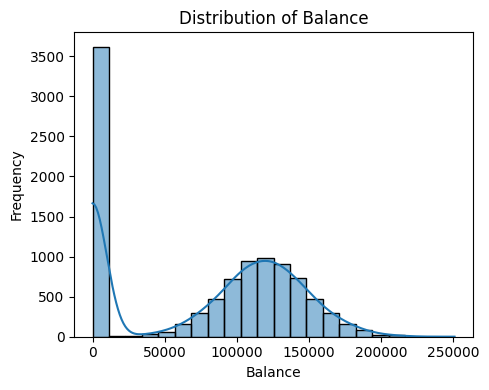

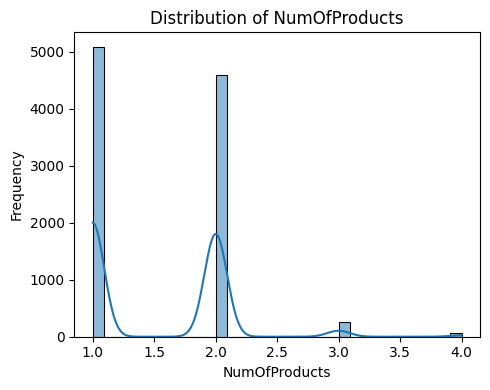

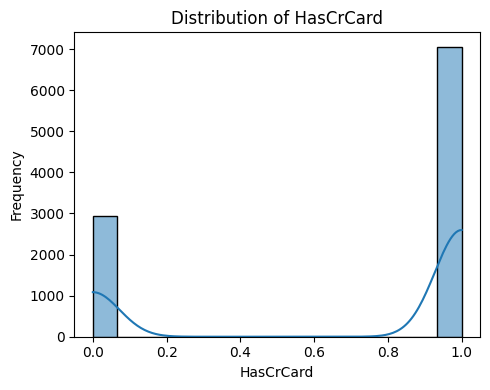

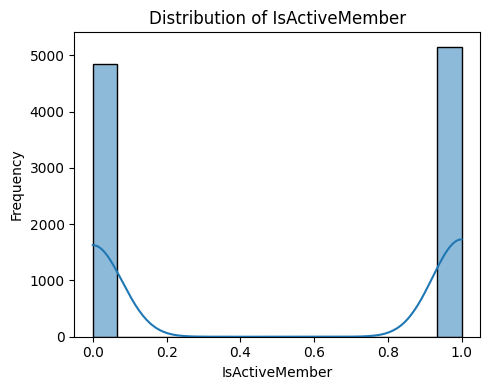

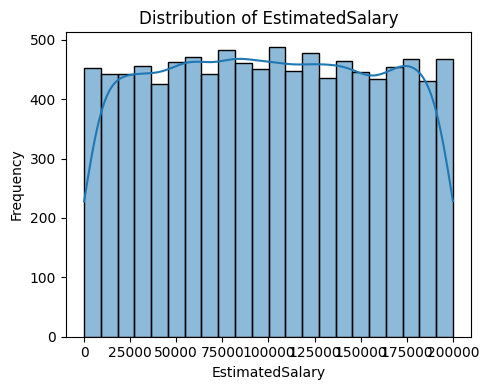

In [10]:
# ------------------------------------------------------------
# 3. DISTRIBUTION OF NUMERICAL FEATURES
# ------------------------------------------------------------

numerical_features = [
    col for col in df1.select_dtypes(include=np.number).columns
    if col != "Exited"
]

for feature in numerical_features:

    plt.figure(figsize=(5, 4))

    sns.histplot(
        data=df1,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

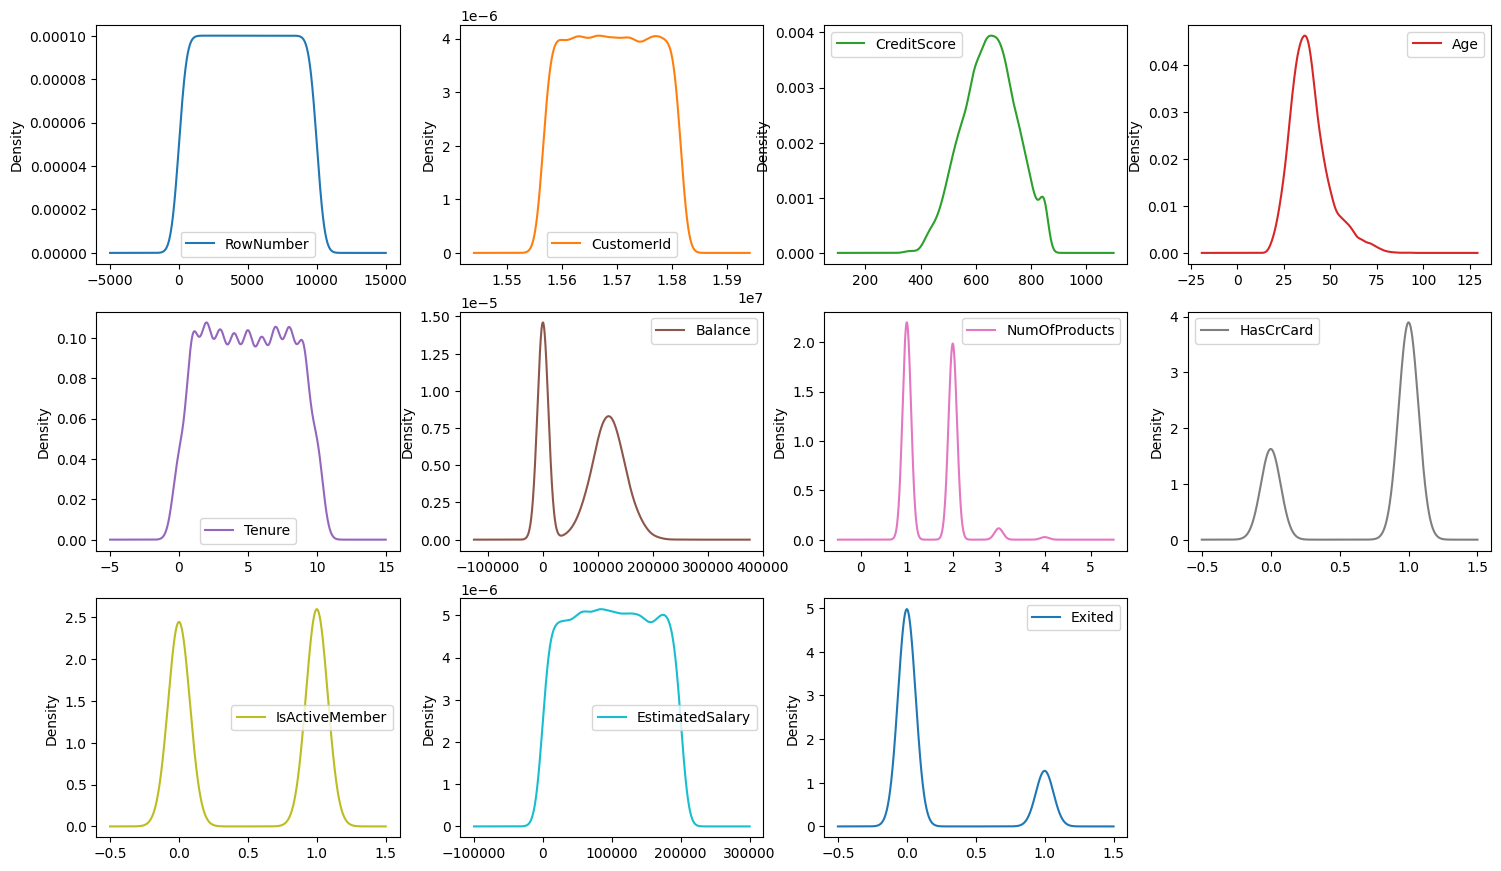

In [11]:
# Create density plots for all numeric features in the DataFrame
numeric_df = df1.select_dtypes(include='number')

numeric_df.plot(kind='density', subplots=True, layout=(5, 4), sharex=False, figsize=(18, 18))

# Save before showing
#plt.savefig('densityDiagram.png', dpi=300, bbox_inches='tight')

plt.show()

###2.1 Visualize target variable

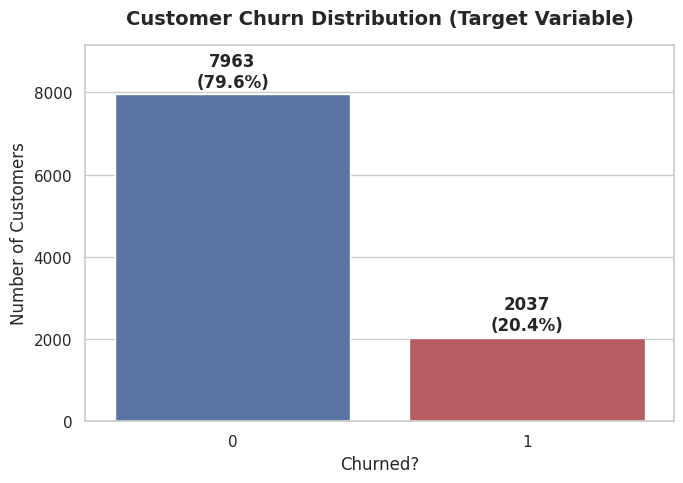

In [12]:
# ------------------------------------------------------------
# 4. TARGET VARIABLE DISTRIBUTION
# ------------------------------------------------------------

# Setup a clean visual theme
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12
#
target_column = 'Exited'
# ------------------------------------------------------

# 2. Calculate the raw counts and percentages
counts = df1['Exited'].value_counts()
percentages = df1['Exited'].value_counts(normalize=True) * 100

# 3. Create the plot
plt.figure(figsize=(7, 5))

# Plot the bars (Using muted blue for 'No' and a warning red for 'Yes' churn)
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=["#4C72B0", "#C44E52"],
    hue=counts.index,
    legend=False
)

# 4. Dynamically add text labels (Count + %) on top of each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,            # X coordinate (center of the bar)
        height + (counts.max() * 0.01),            # Y coordinate (just above the bar)
        f'{int(height)}\n({percentages.iloc[i]:.1f}%)', # The label text
        ha="center",
        va="bottom",
        fontweight='bold'
    )

# 5. Clean up labels and spacing
plt.title("Customer Churn Distribution (Target Variable)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Churned?", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Give a little extra headroom at the top of the y-axis for the text labels
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()

# Save before showing
#plt.savefig('churnDistribution.png', dpi=300, bbox_inches='tight')

# 6. Show the plot (or use plt.savefig('churn_plot.png') to save it)
plt.show()

The target varible is highly imbalanced by a 4:1 ratio, so we will implement SMOTE to balance it out before fitting the model in order to compare model performance.

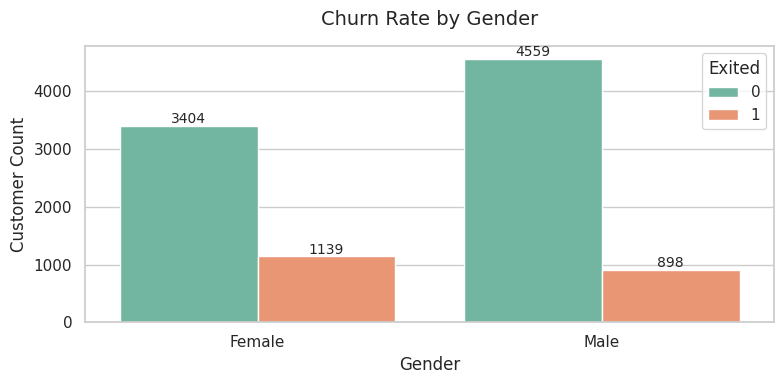

In [13]:
# ------------------------------------------------------------
# 5. NON-NUMERICAL FEATURES AND TARGET VARIABLE
# ------------------------------------------------------------
# Set a clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Plot churn count broken down by gender
ax = sns.countplot(
    data=df1,
    x="Gender",
    hue="Exited",
    palette="Set2"
)

# Add titles and clean up labels
plt.title("Churn Rate by Gender", fontsize=14, pad=15)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)

# Optional: Display exact numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=10,
        )

plt.tight_layout()

#plt.savefig('gender.png', dpi=300, bbox_inches='tight')

plt.show()

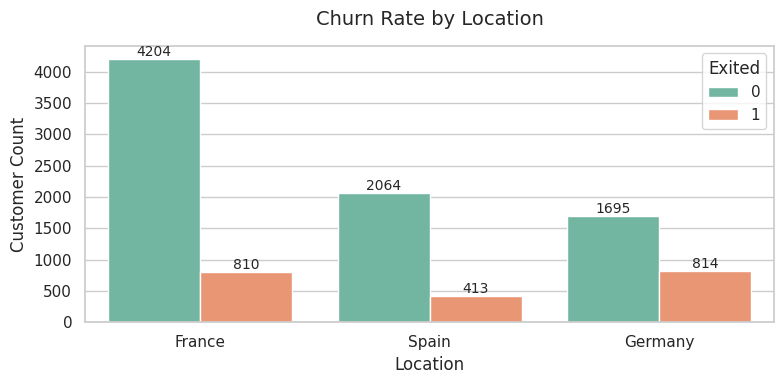

In [14]:
# Set a clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Plot churn count broken down by gender
ax = sns.countplot(
    data=df1,
    x="Geography",
    hue="Exited",
    palette="Set2"
)

# Add titles and clean up labels
plt.title("Churn Rate by Location", fontsize=14, pad=15)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)

# Optional: Display exact numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=10,
        )

plt.tight_layout()

#plt.savefig('location.png', dpi=300, bbox_inches='tight')

plt.show()

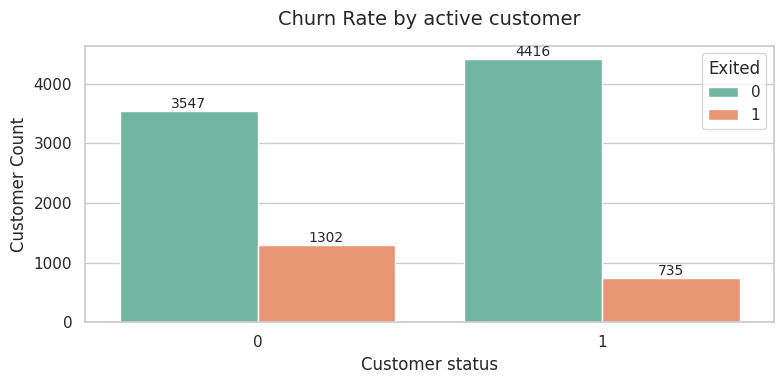

In [15]:
# Set a clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Plot churn count broken down by gender
ax = sns.countplot(
    data=df1,
    x="IsActiveMember",
    hue="Exited",
    palette="Set2"
)

# Add titles and clean up labels
plt.title("Churn Rate by active customer", fontsize=14, pad=15)
plt.xlabel("Customer status", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)

# Optional: Display exact numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=10,
        )

plt.tight_layout()

#plt.savefig('activeCustomer.png', dpi=300, bbox_inches='tight')

plt.show()

##3.0 Feature Engineering

**1.** Columns with private customer information like the name and ID are dropped


In [16]:
df1.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [17]:
## remove name columns
df_new = df1.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1) ## consider removing gender

In [18]:
## View the newly created dataset
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


###3.1 Check for individudal values in categorical variables

In [19]:
df_new.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [20]:
df_new.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [21]:
df_new.Exited.unique()

array([1, 0])

In [22]:
df_new.Tenure.unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

In [23]:
### for feature eng, this new feauture will be added and outcome tested
# if 'TotalCharges' in df_new.columns and 'tenure' in df_new.columns:
#     df_new['AvgMonthlySpend'] = df_new['TotalCharges'] / (df_new['tenure'] + 1)

 Categorical variables are converted to integers using one-hot encoding. The reason for this choice is because we have nominal variables in the dataset.

In [24]:
## encode categorical variables

# df_new = pd.get_dummies(df_new, dtype=int, drop_first=True)
df_new1 = pd.get_dummies(df_new, columns=['Geography', 'Gender'], dtype = int)

We are using tree-based models, so all dummy variables were retained after one-hot encoding since such models are not affected by multicollinearity. Retaining all categories preserves interpretability and allows the model to learn splits more efficiently.

In [25]:
## View the newly created dataset
df_new1.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0


###3.2 SMOTE to balance the target column

In [26]:
## prepare data for train-test split
X = df_new1.drop('Exited', axis=1)
y = df_new1['Exited']

In the split below, we create a calibration set for the purpose of conformity testing (usong MAPIE)

In [27]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# Main train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train/calibration split
X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(X_train.shape)
print(X_calib.shape)
print(X_test.shape)

(6400, 13)
(1600, 13)
(2000, 13)


In [28]:
print("Before SMOTE:")
print(Counter(y_train))

Before SMOTE:
Counter({0: 5096, 1: 1304})


In [29]:
## Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [30]:
## A view to show the balance in the target variable after applying SMOTE
print("After SMOTE:")
print(Counter(y_train_smote))

After SMOTE:
Counter({1: 5096, 0: 5096})


##4.0 Model Comparison

 We fit 3  models and compare metrics to see which model performs better on the test set. The models are Random Forest, XGBoost and LightGBM

#### The models are first fit with training data that is not balanced using SMOTE and then fit with training data that is balanced using SMOTE. We compare metrics afterwards.

In [31]:
## Declare models with basic parameters
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
}

In [32]:
## without SMOTE
results = []

for name, model in models.items():
    print(f"\n===== {name} =====")

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Store results
    results.append([name, acc, prec, rec, f1, roc])


===== Random Forest =====
Accuracy: 0.863
Precision: 0.7955555555555556
Recall: 0.4398034398034398
F1 Score: 0.5664556962025317
ROC-AUC: 0.8524294710735388
Confusion Matrix:
 [[1547   46]
 [ 228  179]]

===== XGBoost =====


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:01:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.86
Precision: 0.7432950191570882
Recall: 0.47665847665847666
F1 Score: 0.5808383233532934
ROC-AUC: 0.8432639110605212
Confusion Matrix:
 [[1526   67]
 [ 213  194]]

===== LightGBM =====
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
Accuracy: 0.855
Precision: 0.7127272727272728
Recall: 0.48157248157248156
F1 Score: 0.5747800586510264
ROC-AUC: 0.8520816656409878
Confusion Matrix:
 [[1514   79]
 [ 211  196]]


In [33]:
## create a dataframe to hold the results
results_df_plain = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print('Results without smote')
print(results_df_plain.sort_values(by="ROC-AUC", ascending=False))

Results without smote
           Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Random Forest     0.863   0.795556  0.439803  0.566456  0.852429
2       LightGBM     0.855   0.712727  0.481572  0.574780  0.852082
1        XGBoost     0.860   0.743295  0.476658  0.580838  0.843264


In [34]:
## Save model

# joblib.dump(xgb_grid.best_estimator_, "models/xgb_model.pkl")
# joblib.dump(X_train.columns.tolist(), "models/feature_columns.pkl")

In [35]:
## With SMOTE

results1 = []

for name, model in models.items():
    print(f"\n===== {name} =====")

    # Train
    model.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Store results
    results1.append([name, acc, prec, rec, f1, roc])


===== Random Forest =====
Accuracy: 0.8445
Precision: 0.6403508771929824
Recall: 0.538083538083538
F1 Score: 0.5847797062750334
ROC-AUC: 0.8424240881868
Confusion Matrix:
 [[1470  123]
 [ 188  219]]

===== XGBoost =====


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:01:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.848
Precision: 0.6426592797783933
Recall: 0.5700245700245701
F1 Score: 0.6041666666666666
ROC-AUC: 0.8448571838402346
Confusion Matrix:
 [[1464  129]
 [ 175  232]]

===== LightGBM =====
[LightGBM] [Info] Number of positive: 5096, number of negative: 5096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 10192, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.846
Precision: 0.6394366197183099
Recall: 0.5577395577395577
F1 Score: 0.5958005249343832
ROC-AUC: 0.848247322823594
Confusion Matrix:
 [[1465  128]
 [ 180  227]]


In [36]:
results_df_smote = pd.DataFrame(
    results1,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print('Results with smote')
print(results_df_smote.sort_values(by="ROC-AUC", ascending=False))

Results with smote
           Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2       LightGBM    0.8460   0.639437  0.557740  0.595801  0.848247
1        XGBoost    0.8480   0.642659  0.570025  0.604167  0.844857
0  Random Forest    0.8445   0.640351  0.538084  0.584780  0.842424


##4.1 GridSearch
We used Gridsearch to obtain the optimal hyperparameters for the models used.

In [37]:
### Hyperparameter optimization
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

lgbm = LGBMClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

lgbm_params = {
    'n_estimators': [100, 200],
    'num_leaves': [31, 50],
    'learning_rate': [0.01, 0.1],
    'max_depth': [-1, 10]
}

In [38]:
### Tune rf model using original data
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best RF Score: 0.8549318660759111


In [39]:

### Tune rf model using smote data
rf_grid_smote = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
rf_grid_smote.fit(X_train_smote, y_train_smote)

print("Best RF Params:", rf_grid_smote.best_params_)
print("Best RF Score:", rf_grid_smote.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF Score: 0.9554448489721103


In [40]:
### tune xgb_grid search using original data
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB Score:", xgb_grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best XGB Score: 0.8649566427361928


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:06:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [41]:
### tune xgb_grid search using smote data
xgb_grid_smote = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid_smote.fit(X_train_smote, y_train_smote)

print("Best XGB Params:", xgb_grid_smote.best_params_)
print("Best XGB Score:", xgb_grid_smote.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:06:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best XGB Score: 0.9571466010036065


In [42]:
### tune Lgbm using original data
lgbm_grid = GridSearchCV(
    estimator=lgbm,
    param_grid=lgbm_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lgbm_grid.fit(X_train, y_train)

print("Best LGBM Params:", lgbm_grid.best_params_)
print("Best LGBM Score:", lgbm_grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
Best LGBM Params: {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}
Best LGBM Score: 0.8592512269437849


In [43]:
### tune lgbm uisng smote data
lgbm_grid_smote = GridSearchCV(
    estimator=lgbm,
    param_grid=lgbm_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lgbm_grid_smote.fit(X_train_smote, y_train_smote)

print("Best LGBM Params:", lgbm_grid_smote.best_params_)
print("Best LGBM Score:", lgbm_grid_smote.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Info] Number of positive: 5096, number of negative: 5096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 10192, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best LGBM Params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 50}
Best LGBM Score: 0.9572672840310119



===== Random Forest (Tuned) =====
ROC-AUC: 0.8642078133603559
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1593
           1       0.61      0.63      0.62       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000


===== XGBoost (Tuned) =====
ROC-AUC: 0.867730596544156
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000


===== LightGBM (Tuned) =====
ROC-AUC: 0.8658890014822219
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.81      0.42      0.56       407

    a

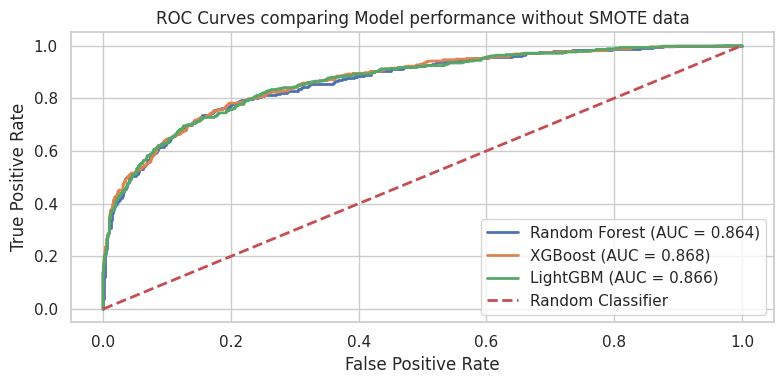

In [44]:
### Evaluate Best Models on Test Set without smote data
models = {
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "LightGBM": lgbm_grid.best_estimator_
}

for name, model in models.items():
    print(f"\n===== {name} (Tuned) =====")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 4))

for name, model in models.items():
    # Predicted probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Compute AUC
    auc = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC = {auc:.3f})")

# Plot random classifier baseline
plt.plot([0, 1], [0, 1],
         linestyle='--',
         linewidth=2,
         label='Random Classifier')

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves comparing Model performance without SMOTE data")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

The XGBoost model performs better on the test set

In [45]:
## Save model


#joblib.dump(xgb_grid.best_estimator_, "xgb_model.pkl")
# joblib.dump(scaler, "models/scaler.pkl")
# joblib.dump(X_train.columns.tolist(), "models/feature_columns.pkl")


===== Random Forest (Tuned) =====
ROC-AUC: 0.8424240881868
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1593
           1       0.64      0.54      0.58       407

    accuracy                           0.84      2000
   macro avg       0.76      0.73      0.74      2000
weighted avg       0.84      0.84      0.84      2000


===== XGBoost (Tuned) =====
ROC-AUC: 0.8462067614609987
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1593
           1       0.65      0.57      0.61       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.76      2000
weighted avg       0.84      0.85      0.85      2000


===== LightGBM (Tuned) =====
ROC-AUC: 0.8445888106905056
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.67      0.54      0.60       407

    acc

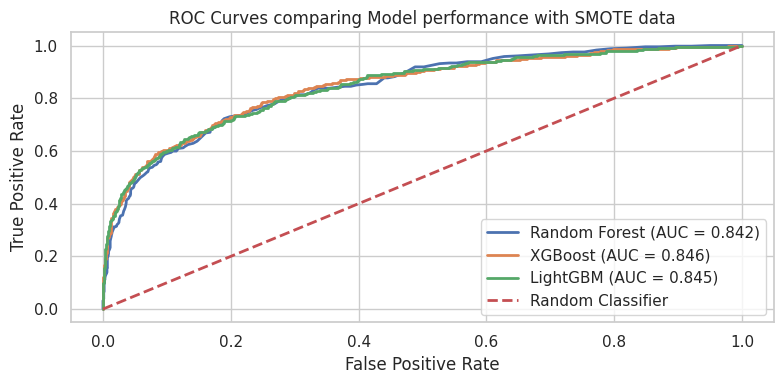

In [46]:
### Evaluate Best Models on Test Set using SMOTE data
models = {
    "Random Forest": rf_grid_smote.best_estimator_,
    "XGBoost": xgb_grid_smote.best_estimator_,
    "LightGBM": lgbm_grid_smote.best_estimator_
}

roc_auc_scores = {}

for name, model in models.items():
    print(f"\n===== {name} (Tuned) =====")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 4))

for name, model in models.items():
    # Predicted probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Compute AUC
    auc = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC = {auc:.3f})")

# Plot random classifier baseline
plt.plot([0, 1], [0, 1],
         linestyle='--',
         linewidth=2,
         label='Random Classifier')

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves comparing Model performance with SMOTE data")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

 We plot the PR curve because the target variable in test set is imbalanced, this is done to guage the performance on real world data

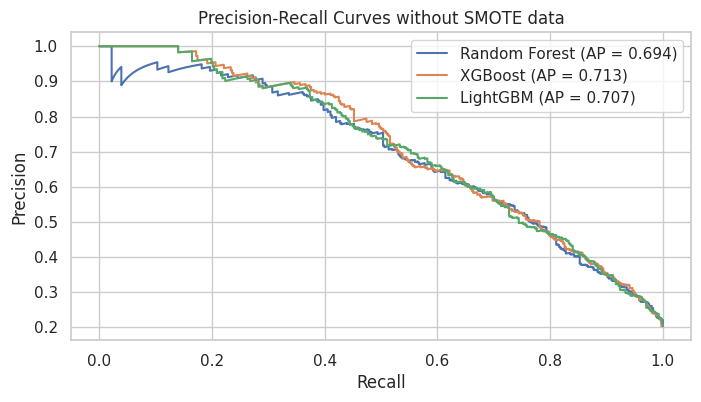

In [47]:
## PR curve using original data
models = {
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "LightGBM": lgbm_grid.best_estimator_
}

plt.figure(figsize=(8, 4))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision,
             label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves without SMOTE data")
plt.legend()
plt.grid(True)

#plt.savefig('PRCurveNonSmote.png', dpi=300, bbox_inches='tight')
plt.show()

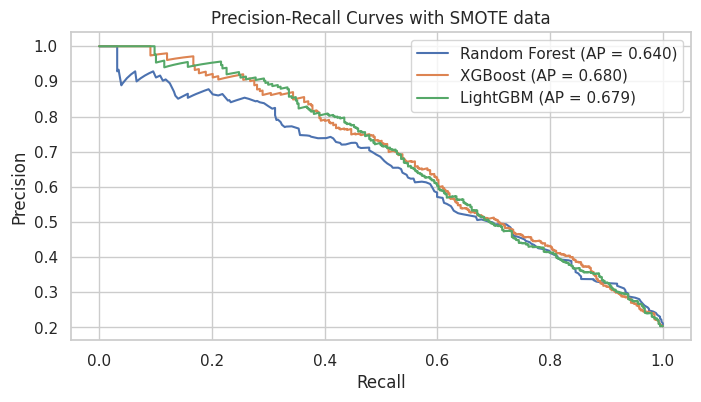

In [48]:
## PR curve using smote data
models = {
    "Random Forest": rf_grid_smote.best_estimator_,
    "XGBoost": xgb_grid_smote.best_estimator_,
    "LightGBM": lgbm_grid_smote.best_estimator_
}

plt.figure(figsize=(8, 4))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision,
             label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves with SMOTE data")
plt.legend()
plt.grid(True)

#plt.savefig('PRCurveSmote.png', dpi=300, bbox_inches='tight')
plt.show()

#### From the chart above XGBoost performs better according to the above plots
XGBoost performs better than the other models in the test set, It performs better both when trained on balanced or imbalanced data.

##4.2 Model Reliability and Explanability
### 4.2.1 Conformity Prediction - using MAPIE

For 0.95 Confidence limit

In [49]:
best_xgb = xgb_grid.best_estimator_

conformal_model = SplitConformalClassifier(
    estimator=best_xgb,
    confidence_level=0.95,
    prefit=True
)

In [50]:
conformal_model.conformalize(
    X_calib,
    y_calib
)

In [51]:
# Generate Conformal Predictions
y_pred, y_sets = conformal_model.predict_set(X_test)

print("First 5 predicted classes:")
print(y_pred[:5])

print("\nFirst 5 conformal prediction sets:")
print(y_sets[:5])


# ---------------------------------------------------------
# Convert MAPIE boolean prediction sets into class labels
# ---------------------------------------------------------

# MAPIE returns prediction sets as boolean membership arrays.
# For binary classification:
#   [True, False]  -> class 0 only
#   [False, True]  -> class 1 only
#   [True, True]   -> both classes
#   [False, False] -> empty set

prediction_sets = []

for pred_set in y_sets:
    # Flatten the returned array
    membership = np.asarray(pred_set).flatten()

    # Identify which classes are included
    classes_in_set = np.where(membership)[0].tolist()

    prediction_sets.append(classes_in_set)


# ---------------------------------------------------------
# Calculate empirical coverage
# ---------------------------------------------------------

coverage = np.mean([
    y_test.iloc[i] in prediction_sets[i]
    for i in range(len(y_test))
])

print(f"\nEmpirical Coverage: {coverage:.4f}")


# ---------------------------------------------------------
# Calculate prediction-set sizes correctly
# ---------------------------------------------------------

set_sizes = [
    len(pred_set)
    for pred_set in prediction_sets
]

avg_set_size = np.mean(set_sizes)

print(f"Average Prediction Set Size: {avg_set_size:.3f}")


# ---------------------------------------------------------
# Count prediction-set categories
# ---------------------------------------------------------

single_class_count = sum(size == 1 for size in set_sizes)
both_classes_count = sum(size == 2 for size in set_sizes)
empty_set_count = sum(size == 0 for size in set_sizes)

total_predictions = len(prediction_sets)

print(f"\nTotal Predictions: {total_predictions}")
print(f"Single-Class Prediction Sets: {single_class_count}")
print(f"Two-Class Prediction Sets: {both_classes_count}")
print(f"Empty Prediction Sets: {empty_set_count}")


# ---------------------------------------------------------
# Calculate percentages
# ---------------------------------------------------------

single_class_pct = (single_class_count / total_predictions) * 100
both_classes_pct = (both_classes_count / total_predictions) * 100
empty_set_pct = (empty_set_count / total_predictions) * 100

print(f"\nSingle-Class Prediction Sets: {single_class_pct:.2f}%")
print(f"Two-Class Prediction Sets: {both_classes_pct:.2f}%")
print(f"Empty Prediction Sets: {empty_set_pct:.2f}%")


# ---------------------------------------------------------
# Identify uncertain predictions
# ---------------------------------------------------------

# A prediction is considered uncertain when both possible
# classes remain in the conformal prediction set.

uncertain_idx = [
    i for i, pred_set in enumerate(prediction_sets)
    if len(pred_set) == 2
]

print(f"\nNumber of Uncertain Predictions: {len(uncertain_idx)}")
print(
    f"Percentage of Uncertain Predictions: "
    f"{(len(uncertain_idx) / total_predictions) * 100:.2f}%"
)


# ---------------------------------------------------------
# Create a results dataframe
# ---------------------------------------------------------

results2 = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": y_pred,
    "Prediction_Set": prediction_sets,
    "Prediction_Set_Size": set_sizes
})


# ---------------------------------------------------------
# Create readable prediction-set labels
# ---------------------------------------------------------

def format_prediction_set(pred_set):
    if pred_set == [0]:
        return "{No Churn}"
    elif pred_set == [1]:
        return "{Churn}"
    elif pred_set == [0, 1]:
        return "{No Churn, Churn}"
    else:
        return "{}"

# ----------------------------------------------------------
# Further breakdown of uncertainty
# ----------------------------------------------------------

results2["Prediction_Set_Label"] = [
    format_prediction_set(pred_set)
    for pred_set in prediction_sets
]


# Display first 10 results
results2.head(10)


# Uncertainty breakdown by actual class
uncertainty_breakdown = pd.crosstab(
    results2["Actual"],
    results2["Prediction_Set_Size"]
)

uncertainty_breakdown.columns = ["Single-class", "Two-class"]
uncertainty_breakdown.index = ["No Churn", "Churn"]

uncertainty_breakdown["Total"] = (
    uncertainty_breakdown["Single-class"] +
    uncertainty_breakdown["Two-class"]
)

uncertainty_breakdown["Two-class (%)"] = (
    uncertainty_breakdown["Two-class"] /
    uncertainty_breakdown["Total"] * 100
)

uncertainty_breakdown

First 5 predicted classes:
[0 0 0 0 0]

First 5 conformal prediction sets:
[[[ True]
  [False]]

 [[ True]
  [False]]

 [[ True]
  [False]]

 [[ True]
  [False]]

 [[ True]
  [False]]]

Empirical Coverage: 0.9565
Average Prediction Set Size: 1.298

Total Predictions: 2000
Single-Class Prediction Sets: 1403
Two-Class Prediction Sets: 597
Empty Prediction Sets: 0

Single-Class Prediction Sets: 70.15%
Two-Class Prediction Sets: 29.85%
Empty Prediction Sets: 0.00%

Number of Uncertain Predictions: 597
Percentage of Uncertain Predictions: 29.85%


,Single-class,Two-class,Total,Two-class (%)
No Churn,1234,359,1593,22.536095
Churn,169,238,407,58.476658


For 0.90 Confidence Interval

In [52]:
best_xgb = xgb_grid.best_estimator_

conformal_model = SplitConformalClassifier(
    estimator=best_xgb,
    confidence_level=0.90,
    prefit=True
)

In [53]:

# conformal_model.fit(
#     X_train,
#     y_train
# )

conformal_model.conformalize(
    X_calib,
    y_calib
)

In [54]:
# Generate Conformal Predictions
y_pred, y_sets = conformal_model.predict_set(X_test)

print("First 5 predicted classes:")
print(y_pred[:5])

print("\nFirst 5 conformal prediction sets:")
print(y_sets[:5])


# ---------------------------------------------------------
# Convert MAPIE boolean prediction sets into class labels
# ---------------------------------------------------------

# MAPIE returns prediction sets as boolean membership arrays.
# For binary classification:
#   [True, False]  -> class 0 only
#   [False, True]  -> class 1 only
#   [True, True]   -> both classes
#   [False, False] -> empty set

prediction_sets = []

for pred_set in y_sets:
    # Flatten the returned array
    membership = np.asarray(pred_set).flatten()

    # Identify which classes are included
    classes_in_set = np.where(membership)[0].tolist()

    prediction_sets.append(classes_in_set)


# ---------------------------------------------------------
# Calculate empirical coverage
# ---------------------------------------------------------

coverage = np.mean([
    y_test.iloc[i] in prediction_sets[i]
    for i in range(len(y_test))
])

print(f"\nEmpirical Coverage: {coverage:.4f}")


# ---------------------------------------------------------
# Calculate prediction-set sizes correctly
# ---------------------------------------------------------

set_sizes = [
    len(pred_set)
    for pred_set in prediction_sets
]

avg_set_size = np.mean(set_sizes)

print(f"Average Prediction Set Size: {avg_set_size:.3f}")


# ---------------------------------------------------------
# Count prediction-set categories
# ---------------------------------------------------------

single_class_count = sum(size == 1 for size in set_sizes)
both_classes_count = sum(size == 2 for size in set_sizes)
empty_set_count = sum(size == 0 for size in set_sizes)

total_predictions = len(prediction_sets)

print(f"\nTotal Predictions: {total_predictions}")
print(f"Single-Class Prediction Sets: {single_class_count}")
print(f"Two-Class Prediction Sets: {both_classes_count}")
print(f"Empty Prediction Sets: {empty_set_count}")


# ---------------------------------------------------------
# Calculate percentages
# ---------------------------------------------------------

single_class_pct = (single_class_count / total_predictions) * 100
both_classes_pct = (both_classes_count / total_predictions) * 100
empty_set_pct = (empty_set_count / total_predictions) * 100

print(f"\nSingle-Class Prediction Sets: {single_class_pct:.2f}%")
print(f"Two-Class Prediction Sets: {both_classes_pct:.2f}%")
print(f"Empty Prediction Sets: {empty_set_pct:.2f}%")


# ---------------------------------------------------------
# Identify uncertain predictions
# ---------------------------------------------------------

# A prediction is considered uncertain when both possible
# classes remain in the conformal prediction set.

uncertain_idx = [
    i for i, pred_set in enumerate(prediction_sets)
    if len(pred_set) == 2
]

print(f"\nNumber of Uncertain Predictions: {len(uncertain_idx)}")
print(
    f"Percentage of Uncertain Predictions: "
    f"{(len(uncertain_idx) / total_predictions) * 100:.2f}%"
)


# ---------------------------------------------------------
# Create a results dataframe
# ---------------------------------------------------------

results2 = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": y_pred,
    "Prediction_Set": prediction_sets,
    "Prediction_Set_Size": set_sizes
})


# ---------------------------------------------------------
# Create readable prediction-set labels
# ---------------------------------------------------------

def format_prediction_set(pred_set):
    if pred_set == [0]:
        return "{No Churn}"
    elif pred_set == [1]:
        return "{Churn}"
    elif pred_set == [0, 1]:
        return "{No Churn, Churn}"
    else:
        return "{}"


results2["Prediction_Set_Label"] = [
    format_prediction_set(pred_set)
    for pred_set in prediction_sets
]


# Display first 10 results
results2.head(10)

First 5 predicted classes:
[0 0 0 0 0]

First 5 conformal prediction sets:
[[[ True]
  [False]]

 [[ True]
  [False]]

 [[ True]
  [False]]

 [[ True]
  [False]]

 [[ True]
  [False]]]

Empirical Coverage: 0.9040
Average Prediction Set Size: 1.097

Total Predictions: 2000
Single-Class Prediction Sets: 1806
Two-Class Prediction Sets: 194
Empty Prediction Sets: 0

Single-Class Prediction Sets: 90.30%
Two-Class Prediction Sets: 9.70%
Empty Prediction Sets: 0.00%

Number of Uncertain Predictions: 194
Percentage of Uncertain Predictions: 9.70%


,Actual,Prediction,Prediction_Set,Prediction_Set_Size,Prediction_Set_Label
0,0,0,[0],1,{No Churn}
1,0,0,[0],1,{No Churn}
2,0,0,[0],1,{No Churn}
3,0,0,[0],1,{No Churn}
4,0,0,[0],1,{No Churn}
5,0,0,[0],1,{No Churn}
6,0,0,[0],1,{No Churn}
7,0,0,[0],1,{No Churn}
8,0,1,"[0, 1]",2,"{No Churn, Churn}"
9,0,0,[0],1,{No Churn}


###4.2.1 SHAP Explainability

In [55]:
## the cells below are theoretical, and have not been integrated into workflow

In [56]:
# best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_
# best_lgbm = lgbm_grid.best_estimator_

In [57]:
model = best_xgb

explainer = shap.TreeExplainer(model)

In [58]:
shap_values = explainer.shap_values(X_test)

####4.2.2 Global Interpretability (Feature Importance)

Direction of impact:

Red → high feature value

Blue → low feature value

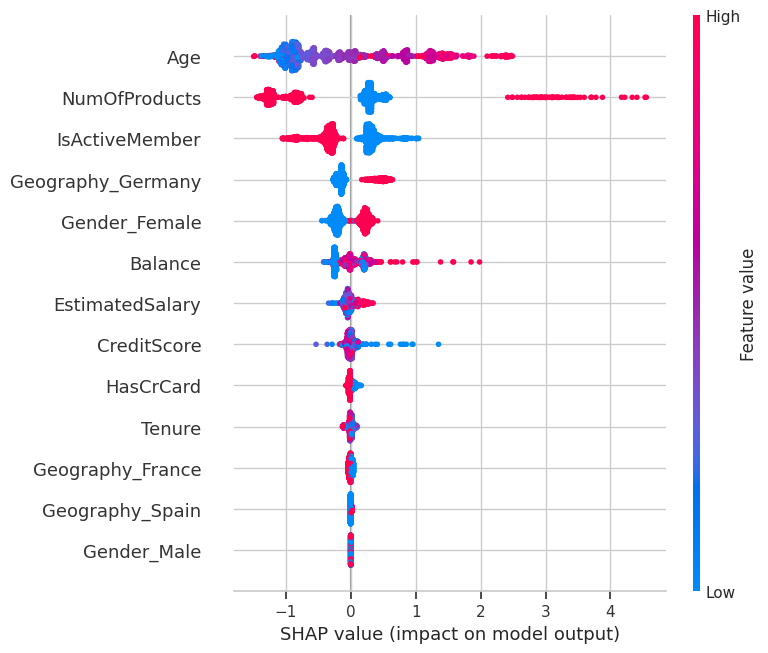

In [59]:
## for creating visuals
shap.summary_plot(shap_values, X_test)

# Save the figure
#plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')

Bar Plot of Feature Importance

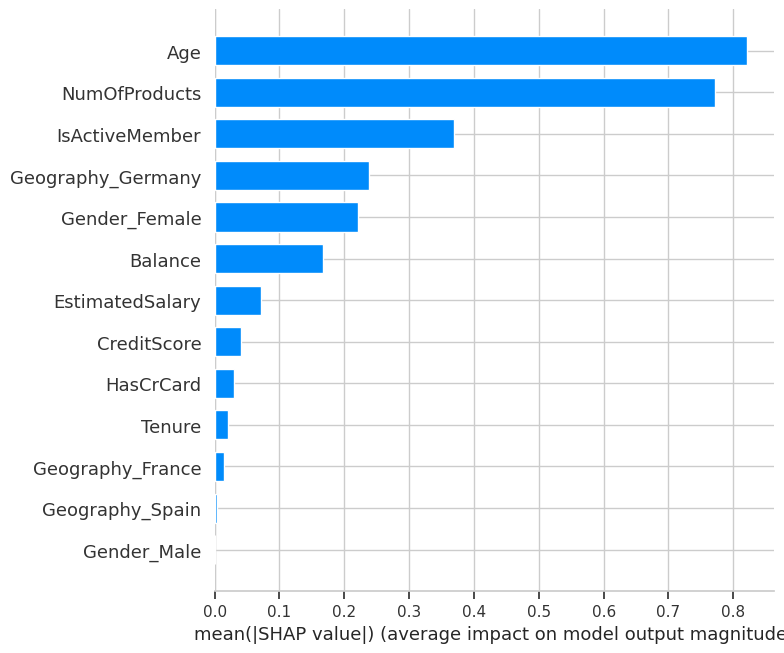

In [60]:
## create cleaner visuals
shap.summary_plot(shap_values, X_test, plot_type="bar")

####4.2.3 Local Interpretability

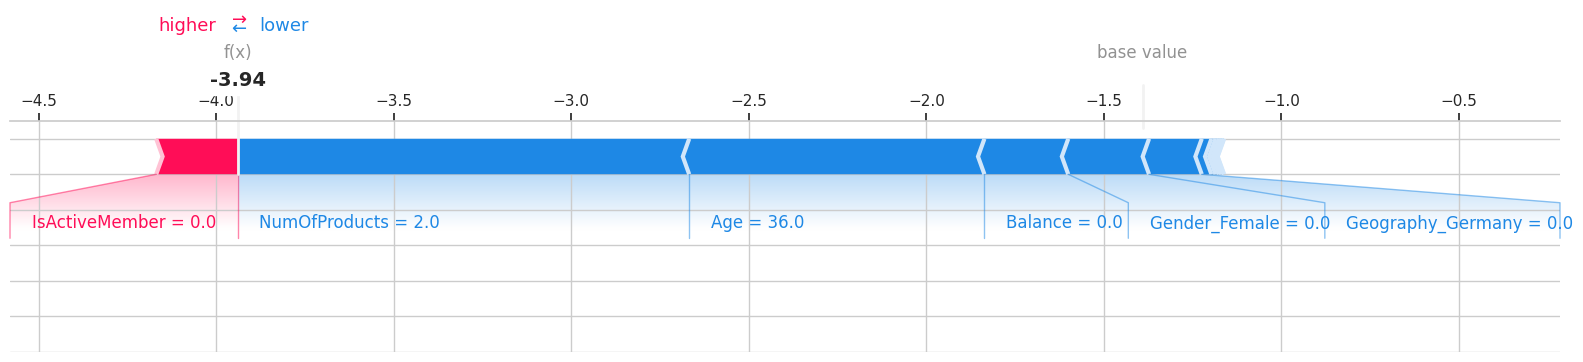

In [61]:
## to see why a particular customer churns
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)

# Save the figure
#plt.savefig('shap_force.png', dpi=300, bbox_inches='tight')

####4.2.4 SHAP Dependence Plots

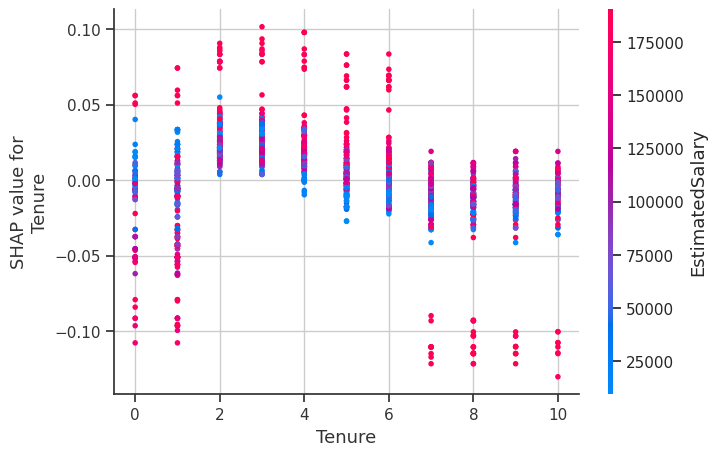

In [62]:
## create dependence plots
shap.dependence_plot("Tenure", shap_values, X_test)

# Save the figure
#plt.savefig('shap_tenure.png', dpi=300, bbox_inches='tight')

SHAP (SHapley Additive exPlanations) was employed to interpret the predictions of the machine learning models. SHAP assigns importance values to features based on their contribution to model predictions using concepts derived from cooperative game theory. This approach enables both global and local interpretability by identifying the most influential variables driving customer churn.

####4.2.5 Partial Dependency Plot

In [63]:
best_xgb = xgb_grid.best_estimator_

In [64]:
df_new1.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male'],
      dtype='object')

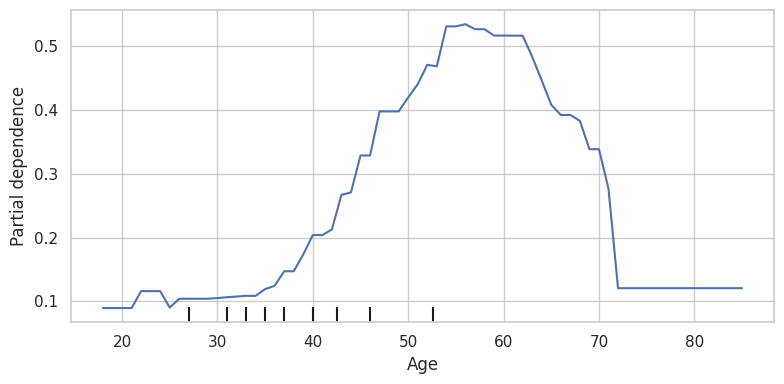

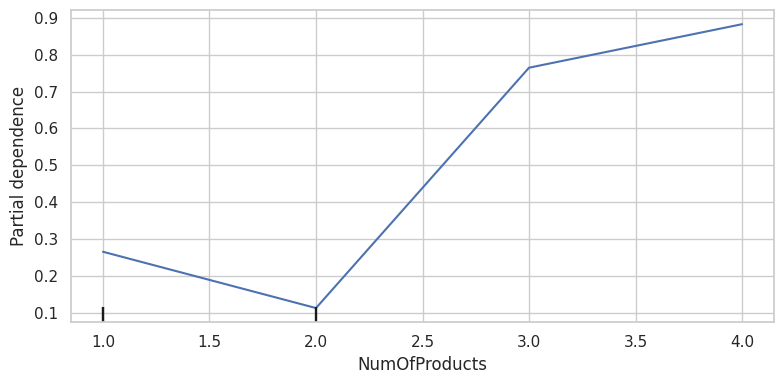

In [65]:
cols = ['Age', 'NumOfProducts']

for i in cols:
  feature = i       # Replace with your feature

  fig, ax = plt.subplots(figsize=(8,4))

  PartialDependenceDisplay.from_estimator(
      estimator=best_xgb,
      X=X_test,
      features=[feature],
      kind="average",
      grid_resolution=100,
      ax=ax
  )

  #plt.title(f"Partial Dependence Plot for {feature}")
  plt.tight_layout()

  # Save the figure
  #plt.savefig('PDP.png', dpi=300, bbox_inches='tight')

  plt.show()